In [26]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import joblib

In [3]:
# ========== CONFIG ==========
DATA_PATH = "/content/WA_Fn-UseC_-Telco-Customer-Churn.csv"  # ubah path jika perlu
OUT_MODEL_PATH = "customer_churn_model.joblib"
RANDOM_STATE = 42
QUICK_RUN = False   # True = cepat (sedikit pohon), False = training lebih baik (lebih lama)
# ============================

In [4]:
# 1) Load
df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
# 2) Drop ID
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

Dataset shape: (7043, 21)


In [5]:
# 3) TotalCharges -> numeric
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan), errors='coerce')
    if df['TotalCharges'].isna().sum() > 0:
        df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [6]:
# 4) Target encode
if 'Churn' not in df.columns:
    raise KeyError("Kolom 'Churn' tidak ditemukan dalam dataset.")
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [7]:
# 5) Feature lists
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'Churn']
categorical_cols = df.select_dtypes(include=['object','category']).columns.tolist()

print("Numeric cols:", numeric_cols)
print("Categorical cols count:", len(categorical_cols))

Numeric cols: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical cols count: 15


In [8]:
# 6) Split
X = df.drop(columns=['Churn'])
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)


In [10]:
# 7) Preprocessor
numeric_transformer = Pipeline([('scaler', StandardScaler())])
categorical_transformer = Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
], remainder='drop')

In [11]:
# 8) Baseline logistic
log_pipe = Pipeline([('pre', preprocessor),
                     ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
print("\nTraining LogisticRegression (baseline)...")
log_pipe.fit(X_train, y_train)
y_pred_lr = log_pipe.predict(X_test)
y_prob_lr = log_pipe.predict_proba(X_test)[:,1]
print("Logistic Regression report:\n", classification_report(y_test, y_pred_lr, digits=4))
print("Logistic ROC AUC:", round(roc_auc_score(y_test, y_prob_lr),4))


Training LogisticRegression (baseline)...
Logistic Regression report:
               precision    recall  f1-score   support

           0     0.8488    0.8947    0.8711      1035
           1     0.6572    0.5588    0.6040       374

    accuracy                         0.8055      1409
   macro avg     0.7530    0.7268    0.7376      1409
weighted avg     0.7979    0.8055    0.8002      1409

Logistic ROC AUC: 0.8419


In [12]:
# 9) RandomForest (quick or full)
if QUICK_RUN:
    rf = RandomForestClassifier(n_estimators=30, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)
    rf_pipe = Pipeline([('pre', preprocessor), ('clf', rf)])
    print("\nTraining RandomForest (quick)...")
    rf_pipe.fit(X_train, y_train)
    best_model = rf_pipe
else:
    rf_pipe = Pipeline([('pre', preprocessor),
                        ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))])
    # Grid search kecil (sesuaikan jika punya waktu)
    param_grid = {
        'clf__n_estimators': [100, 200],
        'clf__max_depth': [8, 12, None],
        'clf__min_samples_split': [2, 5]
    }
    print("\nRunning GridSearchCV untuk RandomForest (akan memakan waktu)...")
    grid = GridSearchCV(rf_pipe, param_grid, scoring='roc_auc', cv=3, n_jobs=-1, verbose=2)
    grid.fit(X_train, y_train)
    print("Best params:", grid.best_params_)
    best_model = grid.best_estimator_


Running GridSearchCV untuk RandomForest (akan memakan waktu)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'clf__max_depth': 8, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}


In [13]:
# 10) Evaluate best model
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]
print("\nBest model classification report:\n", classification_report(y_test, y_pred, digits=4))
print("Best model ROC AUC:", round(roc_auc_score(y_test, y_prob),4))


Best model classification report:
               precision    recall  f1-score   support

           0     0.8426    0.9101    0.8751      1035
           1     0.6804    0.5294    0.5955       374

    accuracy                         0.8091      1409
   macro avg     0.7615    0.7198    0.7353      1409
weighted avg     0.7995    0.8091    0.8009      1409

Best model ROC AUC: 0.8432


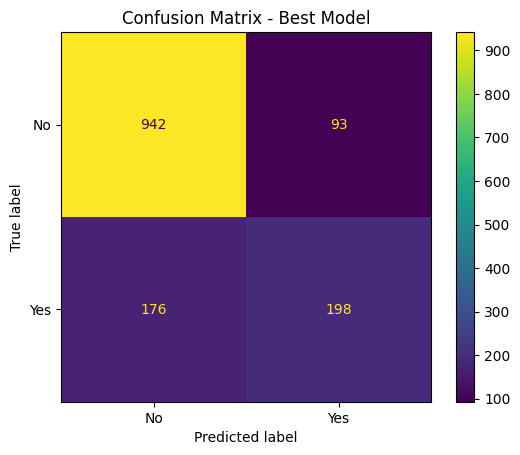

In [14]:
# 11) Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No','Yes'])
disp.plot()
plt.title("Confusion Matrix - Best Model")
plt.show()

In [15]:
# 12) Save model
joblib.dump(best_model, OUT_MODEL_PATH)
print(f"Model tersimpan di: {OUT_MODEL_PATH}")

Model tersimpan di: customer_churn_model.joblib


In [16]:
# 13) Feature importance (opsional, jika RandomForest digunakan)
try:
    clf = best_model.named_steps['clf']
    if hasattr(clf, 'feature_importances_'):
        # get feature names after preprocessing
        # careful: OneHotEncoder expands categorical features
        cat_encoder = best_model.named_steps['pre'].named_transformers_['cat'].named_steps['onehot']
        cat_names = list(cat_encoder.get_feature_names_out(categorical_cols))
        feature_names = numeric_cols + cat_names
        importances = clf.feature_importances_
        imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)
        print("\nTop 10 feature importances:\n", imp_df.head(10).to_string(index=False))
except Exception as e:
    print("Tidak dapat menampilkan feature importances:", e)


Top 10 feature importances:
                        feature  importance
                        tenure    0.145472
       Contract_Month-to-month    0.119384
                  TotalCharges    0.109498
                MonthlyCharges    0.068717
             OnlineSecurity_No    0.067696
   InternetService_Fiber optic    0.059299
                TechSupport_No    0.057314
PaymentMethod_Electronic check    0.048839
             Contract_Two year    0.036467
           InternetService_DSL    0.023028


In [17]:
MODEL_PATH = "/content/customer_churn_model.joblib"  # model tersimpan

In [20]:
model = joblib.load(MODEL_PATH)
print("Model berhasil dimuat dari file:", MODEL_PATH)

Model berhasil dimuat dari file: /content/customer_churn_model.joblib


In [21]:
# 5. Prediksi
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [22]:
# 6. Laporan hasil
print("\n=== Laporan Klasifikasi ===")
print(classification_report(y_test, y_pred, digits=4))
print("ROC AUC Score:", round(roc_auc_score(y_test, y_prob), 4))


=== Laporan Klasifikasi ===
              precision    recall  f1-score   support

           0     0.8426    0.9101    0.8751      1035
           1     0.6804    0.5294    0.5955       374

    accuracy                         0.8091      1409
   macro avg     0.7615    0.7198    0.7353      1409
weighted avg     0.7995    0.8091    0.8009      1409

ROC AUC Score: 0.8432


In [23]:
# 7. Gabungkan hasil ke tabel
pred_df = X_test.copy()
pred_df["Actual"] = y_test.values
pred_df["Predicted"] = y_pred
pred_df["Prob_Yes"] = y_prob

print("\nContoh hasil prediksi:")
print(pred_df.head(10))


Contoh hasil prediksi:
      gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
437     Male              0     Yes        Yes      72          Yes   
2280  Female              1      No         No       8          Yes   
2235  Female              0     Yes        Yes      41          Yes   
4460    Male              0     Yes         No      18          Yes   
3761  Female              0     Yes         No      72          Yes   
5748  Female              0      No         No      21          Yes   
3568  Female              0      No         No      21          Yes   
2976    Male              0      No        Yes      19          Yes   
5928  Female              0     Yes        Yes      61          Yes   
1639    Male              1      No         No      17          Yes   

     MultipleLines InternetService       OnlineSecurity         OnlineBackup  \
437            Yes     Fiber optic                  Yes                  Yes   
2280           Yes     Fiber optic

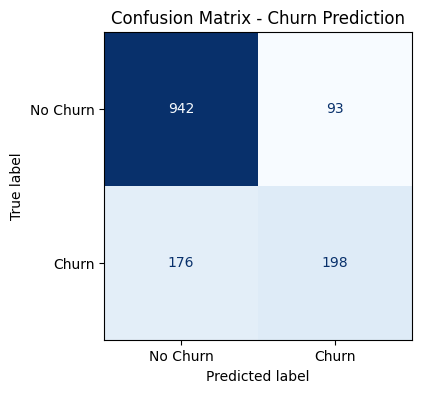

In [24]:
# 8. === GRAFIK VISUALISASI ===

# --- a. Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix - Churn Prediction")
plt.show()


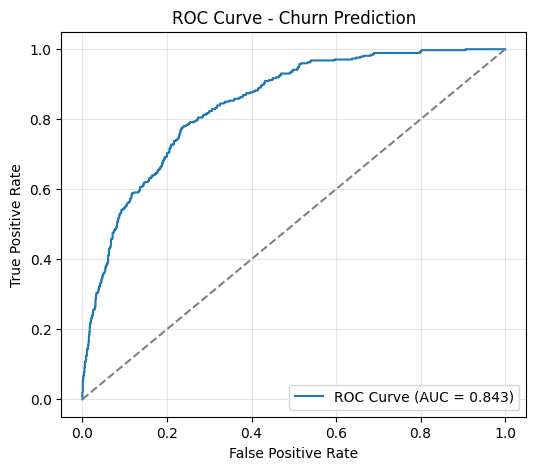

In [27]:
# --- b. ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Churn Prediction")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

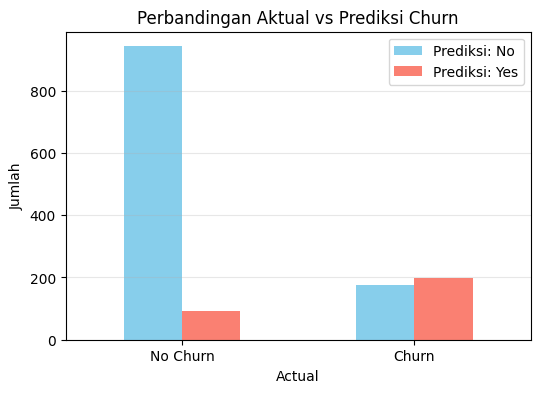

In [28]:
# --- c. Perbandingan aktual vs prediksi (bar chart) ---
counts = pd.crosstab(pred_df["Actual"], pred_df["Predicted"])
counts.plot(kind="bar", figsize=(6, 4), color=["skyblue", "salmon"])
plt.title("Perbandingan Aktual vs Prediksi Churn")
plt.xlabel("Actual")
plt.ylabel("Jumlah")
plt.xticks(ticks=[0, 1], labels=["No Churn", "Churn"], rotation=0)
plt.legend(["Prediksi: No", "Prediksi: Yes"])
plt.grid(axis="y", alpha=0.3)
plt.show()

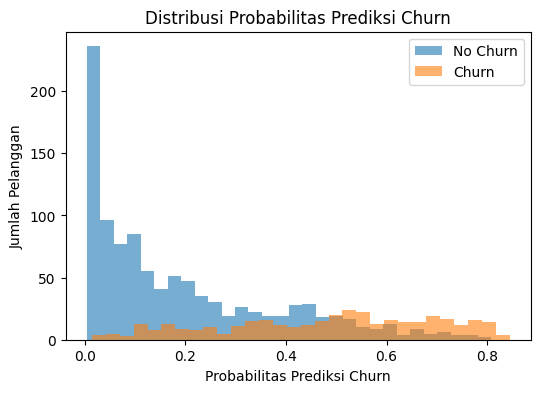

In [29]:
# --- d. Distribusi probabilitas churn ---
plt.figure(figsize=(6, 4))
plt.hist(y_prob[y_test == 0], bins=30, alpha=0.6, label="No Churn")
plt.hist(y_prob[y_test == 1], bins=30, alpha=0.6, label="Churn")
plt.xlabel("Probabilitas Prediksi Churn")
plt.ylabel("Jumlah Pelanggan")
plt.title("Distribusi Probabilitas Prediksi Churn")
plt.legend()
plt.show()